# Titanic Codealong END
Please note that we have updated the code so that it works for newer versions of pandas. You may notice small changes between this code and that written in the codealong.

**Old code**
* `passengers.corr()`
* `passengers.groupby(by="Pclass").mean()`

**New code**: set numeric_only to True
* `passengers.corr(numeric_only = True)`
* `passengers.groupby(by="Pclass").mean(numeric_only = True)`

In [1]:
import pandas as pd

In [2]:
passengers = pd.read_csv('./data/titanic_kaggle_train.csv')
passengers
# https://www.kaggle.com/competitions/titanic/data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Q_A: What types of data we know about passangers? How are they distributed?
A_A: There are 891 passengers, we know 12 different things about each passenger. Numeric values like Age (mean 30) and Fare, but also some categorical information like their passenger class (spans between 1 and 3).

In [3]:
# visualisations:
print("Column names and their types:")
passengers.info()


Column names and their types:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
passengers.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
passengers.Pclass.value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [6]:
passengers.Parch.value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [7]:
passengers.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [8]:
passengers.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
passengers.Pclass.isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Pclass, Length: 891, dtype: bool

# Question B

**Q: How are Age and Fare distriubuted?**

A: Age was distributed between 0 and 80, with mean of 29.7. Data seems to be right-skewed, with some underaged travellers. There seems to be a large group of children, but only those below 1 year old have age detailed in months. Fare has a mean of 32, with one passenger paying 512, and 14 of them paying 0. Some of the 0 fare payers were employees. Tickets of class 1 seemed most expensive (avg 84 $), than class 2 (21 $) and 3 (14 $).

In [10]:
passengers.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

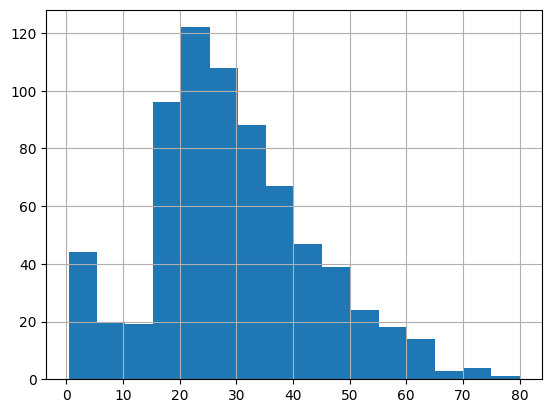

In [11]:
passengers.Age.hist(bins=16)

<Axes: >

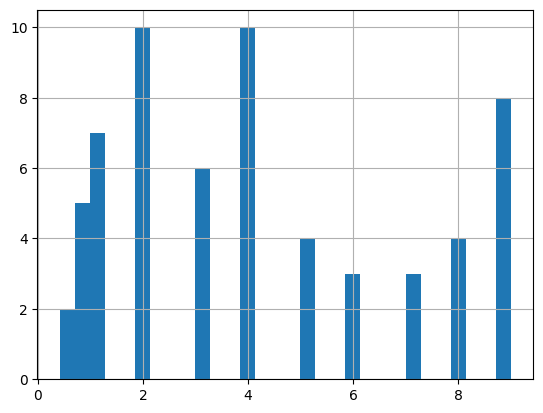

In [12]:
passengers[ passengers.Age < 10  ].Age.hist(bins=30)

In [13]:
passengers[ (passengers.Age > 1) & (passengers.Age <=2) ].PassengerId.count()

np.int64(10)

In [14]:
passengers.Fare.describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: >

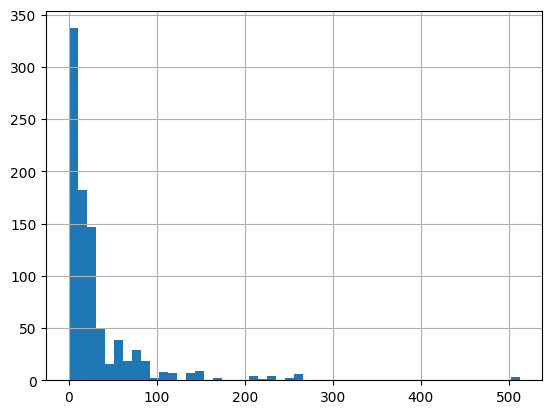

In [15]:
passengers.Fare.hist(bins=50)

<Axes: >

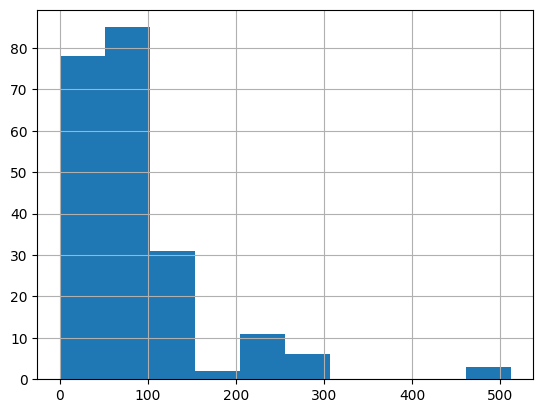

In [16]:
passengers[ passengers.Pclass == 1 ].Fare.hist(bins=10)

<Axes: >

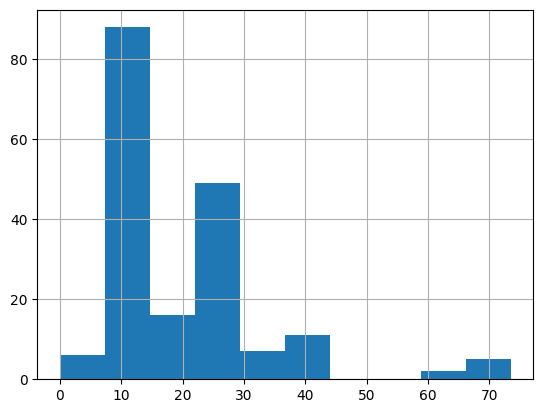

In [17]:
passengers[ passengers.Pclass == 2 ].Fare.hist(bins=10)

<Axes: >

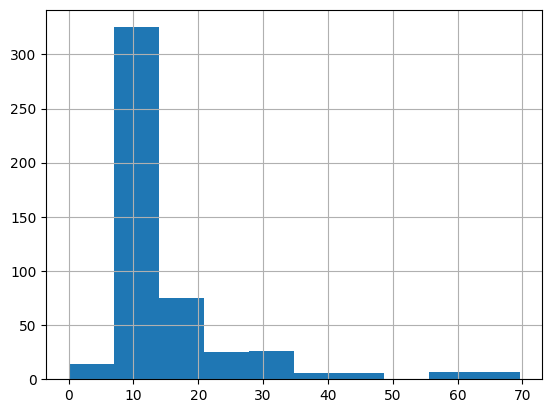

In [18]:
passengers[ passengers.Pclass == 3 ].Fare.hist(bins=10)

<Axes: >

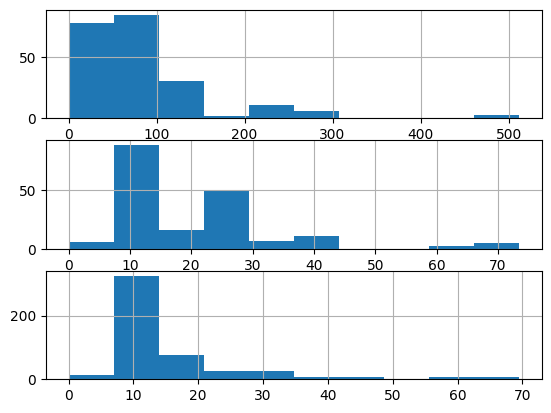

In [53]:
import matplotlib.pyplot as plt
Fig, axs = plt.subplots(3,1)
passengers[ passengers.Pclass == 1 ].Fare.hist(bins=10, ax = axs[0])
passengers[ passengers.Pclass == 2 ].Fare.hist(bins=10, ax = axs[1])
passengers[ passengers.Pclass == 3 ].Fare.hist(bins=10, ax = axs[2])

In [54]:
passengers.groupby(by="Pclass").Fare.mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [21]:
passengers[    passengers.Fare == 0   ].PassengerId.count()

np.int64(15)

# Question C:

Q: when we group passengers, what can we see about survival and fares?
A: Looking at passenger class, people with better class tickets survived more (62% for class 1, with mean of all passengers being 38%). People with 3rd class tickets seemed to be younger and more likely to travel alone. 60% of the travellers travelled alone. Largest group had 11 people.

In [22]:
passengers.Survived.mean()

np.float64(0.3838383838383838)

In [23]:
# passengers[ passengers.Sex == 'male' ].Survived.value_counts().plot( kind = 'barh')
# passengers[ passengers.Sex == 'female' ].Survived.value_counts().plot( kind = 'barh')

In [24]:
passengers.groupby(by=[ "Sex", "Pclass"]).Survived.mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [34]:
passengers.groupby(by="Pclass").mean(numeric_only = True)

,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,461.597222,0.629630,38.233441,0.416667,0.356481,84.154687
2,445.956522,0.472826,29.877630,0.402174,0.380435,20.662183
3,439.154786,0.242363,25.140620,0.615071,0.393075,13.675550


In [33]:
passengers[ passengers.Age < 18 ].groupby(by="Survived").mean(numeric_only = True)

,PassengerId,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,,
0,414.865385,2.923077,10.394231,2.269231,1.076923,26.95489
1,441.442623,2.295082,7.888033,0.770492,1.032787,34.85731


In [35]:
passengers['GroupSize'] = passengers.apply( lambda row: row.SibSp + row.Parch + 1, axis=1)

In [36]:
def group_size(row):
    return row.SibSp + row.Parch + 1

passengers['GroupSize'] = passengers.apply(group_size,  axis=1)

In [37]:
passengers.groupby(by='GroupSize').count()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
GroupSize,,,,,,,,,,,,
1,537,537,537,537,537,404,537,537,537,537,94,535
2,161,161,161,161,161,139,161,161,161,161,66,161
3,102,102,102,102,102,93,102,102,102,102,29,102
4,29,29,29,29,29,27,29,29,29,29,9,29
5,15,15,15,15,15,11,15,15,15,15,2,15
6,22,22,22,22,22,22,22,22,22,22,4,22
7,12,12,12,12,12,12,12,12,12,12,0,12
8,6,6,6,6,6,6,6,6,6,6,0,6
11,7,7,7,7,7,0,7,7,7,7,0,7


In [38]:
type(passengers)

pandas.DataFrame

In [39]:
type(passengers.Age)

pandas.Series

In [40]:
passengers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,GroupSize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


# question D

are variables correlating?

In [42]:
passengers.corr(numeric_only = True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,GroupSize
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138
GroupSize,-0.040143,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000


In [43]:
passengers.isnull().Age.mean(numeric_only = True)

np.float64(0.19865319865319866)

In [44]:
passengers[ passengers.Age.isnull() ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,GroupSize
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,1
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,1
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,1
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,1
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,11
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,1
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,1


In [45]:
passengers.Age.fillna(value = passengers.Age.mean() )

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

# Question E

Q: Can we use simple Machine learning to fill in missing data (eg. Age)
A: (this was just an experiment) After turning the categorical values into numbers, we used Linear Regression to predict Age.

In [47]:
from sklearn.linear_model import LinearRegression

In [50]:
passengers[ passengers.Embarked.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,GroupSize
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,1


In [51]:
# make categorical variables actually categorical
passengersCat = passengers.copy()
passengersCat.Sex = passengersCat.Sex.map({'male':0, 'female':1})
passengersCat.Embarked = passengersCat.Embarked.map({'C':0, 'S':1, 'Q':2}).fillna(3)
passengersCat.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    float64
 12  GroupSize    891 non-null    int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 90.6 KB


In [52]:
passengersCat.Embarked.value_counts()

Embarked
1.0    644
0.0    168
2.0     77
3.0      2
Name: count, dtype: int64

In [ ]:
lr  = LinearRegression()

passWithAge = passengersCat[ passengersCat.Age.isnull() == False ].copy()
passWithoutAge = passengersCat[ passengersCat.Age.isnull() == True ].copy()

train_x = passWithAge[ ['Pclass', 'Sex', 'Fare', 'Embarked', 'PassengerId'] ]
train_y = passWithAge.Age

lr.fit( train_x, train_y )

test_x = passWithoutAge[ ['Pclass', 'Sex', 'Fare', 'Embarked', 'PassengerId']]

test_y = lr.predict(test_x)
passWithoutAge.Age = test_y.round(0)

In [ ]:
passWithoutAge.head(20)